1. Importing Libraries

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np

2. Load Dataset

In [28]:
# Load the dataset
df = pd.read_csv("AdventureWorks Customer Lookup.csv", encoding="ISO-8859-1")

# Preview dataset
df.head()

,CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner
0,11000,MR.,JON,YANG,1966-04-08,M,M,jon24@adventure-works.com,90000.0,2.0,Bachelors,Professional,Y
1,11001,MR.,EUGENE,HUANG,1965-05-14,S,M,eugene10@adventure-works.com,60000.0,3.0,Bachelors,Professional,N
2,11002,MR.,RUBEN,TORRES,1965-08-12,M,M,ruben35@adventure-works.com,60000.0,3.0,Bachelors,Professional,Y
3,11003,MS.,CHRISTY,ZHU,1968-02-15,S,F,christy12@adventure-works.com,70000.0,0.0,Bachelors,Professional,N
4,11004,MRS.,ELIZABETH,JOHNSON,1968-08-08,S,F,elizabeth5@adventure-works.com,80000.0,5.0,Bachelors,Professional,Y


3. Dataset Overview

In [29]:
# Check dataset structure
df.info()

# Check number of rows and columns
print(df.shape)

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18154 entries, 0 to 18153
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerKey     18153 non-null  object 
 1   Prefix          18021 non-null  object 
 2   FirstName       18148 non-null  object 
 3   LastName        18148 non-null  object 
 4   BirthDate       18151 non-null  object 
 5   MaritalStatus   18148 non-null  object 
 6   Gender          18018 non-null  object 
 7   EmailAddress    18148 non-null  object 
 8   AnnualIncome    18148 non-null  float64
 9   TotalChildren   18148 non-null  float64
 10  EducationLevel  18148 non-null  object 
 11  Occupation      18148 non-null  object 
 12  HomeOwner       18148 non-null  object 
dtypes: float64(2), object(11)
memory usage: 1.8+ MB
(18154, 13)


,AnnualIncome,TotalChildren
count,18148.000000,18148.000000
mean,57269.120564,1.843619
std,32236.535573,1.613203
min,10000.000000,0.000000
25%,30000.000000,0.000000
50%,60000.000000,2.000000
75%,70000.000000,3.000000
max,170000.000000,5.000000


4. Check Duplicate Rows

In [30]:
# Check duplicate rows
df.duplicated().sum()

np.int64(2)

5. Remove Duplicate Rows

In [31]:
# Remove duplicates
df = df.drop_duplicates()

# Check duplicates again
print(df.duplicated().sum())

# Check dataset shape
df.shape

0


(18152, 13)

6. Check Missing Values

In [32]:
# Check missing values
df.isnull().sum()

CustomerKey         1
Prefix            133
FirstName           4
LastName            4
BirthDate           3
MaritalStatus       4
Gender            134
EmailAddress        4
AnnualIncome        4
TotalChildren       4
EducationLevel      4
Occupation          4
HomeOwner           4
dtype: int64

7. Handle Missing Values 

In [33]:
# Remove rows with missing values in these columns
df = df.dropna(subset=[
    'FirstName','LastName','BirthDate','MaritalStatus','EmailAddress',
    'AnnualIncome','TotalChildren','EducationLevel','Occupation','HomeOwner'
])
df['Prefix'] = df['Prefix'].fillna(df['Prefix'].mode()[0])
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
print(df.isnull().sum())

CustomerKey       0
Prefix            0
FirstName         0
LastName          0
BirthDate         0
MaritalStatus     0
Gender            0
EmailAddress      0
AnnualIncome      0
TotalChildren     0
EducationLevel    0
Occupation        0
HomeOwner         0
dtype: int64


8. Fix Data Types

In [34]:
# Step 1: Check original datatypes ---
print("Before conversion:")
print(df.info())

# Step 2: Convert datatypes ---

# Numeric / ID
df['CustomerKey'] = df['CustomerKey'].astype('Int64')
df['AnnualIncome'] = df['AnnualIncome'].astype('Int64')
df['TotalChildren'] = df['TotalChildren'].astype('Int64')

# Dates
df['BirthDate'] = pd.to_datetime(df['BirthDate'])

# Categorical columns
categorical_cols = ['Prefix', 'MaritalStatus', 'Gender', 'EducationLevel', 'Occupation', 'HomeOwner']
df[categorical_cols] = df[categorical_cols].astype('category')

# Step 3: Check datatypes after conversion ---
print("\nAfter conversion:")
print(df.info())

Before conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 18148 entries, 0 to 18147
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerKey     18148 non-null  object 
 1   Prefix          18148 non-null  object 
 2   FirstName       18148 non-null  object 
 3   LastName        18148 non-null  object 
 4   BirthDate       18148 non-null  object 
 5   MaritalStatus   18148 non-null  object 
 6   Gender          18148 non-null  object 
 7   EmailAddress    18148 non-null  object 
 8   AnnualIncome    18148 non-null  float64
 9   TotalChildren   18148 non-null  float64
 10  EducationLevel  18148 non-null  object 
 11  Occupation      18148 non-null  object 
 12  HomeOwner       18148 non-null  object 
dtypes: float64(2), object(11)
memory usage: 1.9+ MB
None

After conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 18148 entries, 0 to 18147
Data columns (total 13 columns):
 #   Column          

9. Clean Text Columns

In [35]:
# Define columns by formatting type
upper_cols = ['Prefix', 'MaritalStatus', 'Gender', 'HomeOwner']
title_cols = ['FirstName', 'LastName', 'EducationLevel', 'Occupation']
lower_cols = ['EmailAddress']

# Apply formatting
for col in upper_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()

for col in title_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

for col in lower_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

10. check unique categories

In [ ]:
# Check unique values in categorical columns
unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': [df[col].nunique() for col in df.columns],
    'Sample_Values': [df[col].unique()[:5] for col in df.columns]  
# first 5 unique values as sample
})

# Display summary
print(unique_summary)

            Column  Unique_Count  \
0      CustomerKey         18148   
1           Prefix             3   
2        FirstName           666   
3         LastName           372   
4        BirthDate          8190   
5    MaritalStatus             2   
6           Gender             2   
7     EmailAddress         18148   
8     AnnualIncome            16   
9    TotalChildren             6   
10  EducationLevel             5   
11      Occupation             5   
12       HomeOwner             2   

                                        Sample_Values  
0                 [11000, 11001, 11002, 11003, 11004]  
1                                    [MR., MS., MRS.]  
2            [Jon, Eugene, Ruben, Christy, Elizabeth]  
3                 [Yang, Huang, Torres, Zhu, Johnson]  
4   [1966-04-08 00:00:00, 1965-05-14 00:00:00, 196...  
5                                              [M, S]  
6                                              [M, F]  
7   [jon24@adventure-works.com, eugene10@advent

11. Remove unnecessary columns

In [37]:
# columns not useful for analysis
remove_cols = ['FirstName','LastName','EmailAddress']
df = df.drop(columns= remove_cols)

In [42]:
df.columns

Index(['CustomerKey', 'Prefix', 'Gender', 'Age', 'MaritalStatus',
       'EducationLevel', 'Occupation', 'AnnualIncome', 'TotalChildren',
       'HomeOwner'],
      dtype='object')

12.Feature engineering

In [ ]:
# Add Age column from birthdate
df['Age'] = 2026 - df['BirthDate'].dt.year
df = df.drop(columns=['BirthDate'])

In [40]:
df.columns

Index(['CustomerKey', 'Prefix', 'MaritalStatus', 'Gender', 'AnnualIncome',
       'TotalChildren', 'EducationLevel', 'Occupation', 'HomeOwner', 'Age'],
      dtype='object')

13. Arrange columns

In [41]:
# Arrange columns in proper order
df = df[['CustomerKey',
        'Prefix',
        'Gender',
        'Age',
        'MaritalStatus',
        'EducationLevel',
        'Occupation',
        'AnnualIncome',
        'TotalChildren',
        'HomeOwner']]

# Check dataset
df.head()

,CustomerKey,Prefix,Gender,Age,MaritalStatus,EducationLevel,Occupation,AnnualIncome,TotalChildren,HomeOwner
0,11000,MR.,M,60,M,Bachelors,Professional,90000,2,Y
1,11001,MR.,M,61,S,Bachelors,Professional,60000,3,N
2,11002,MR.,M,61,M,Bachelors,Professional,60000,3,Y
3,11003,MS.,F,58,S,Bachelors,Professional,70000,0,N
4,11004,MRS.,F,58,S,Bachelors,Professional,80000,5,Y


14. Outlier detection

In [43]:
#Import libraries
import matplotlib.pyplot as plt

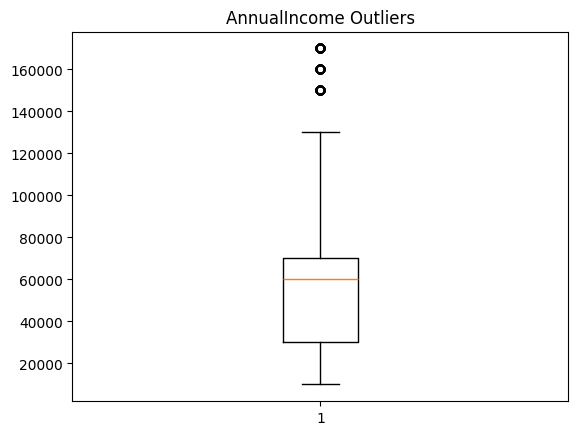

In [44]:
# Using Boxplot for AnnualIncome Outlier
plt.boxplot(df['AnnualIncome'])
plt.title("AnnualIncome Outliers")
plt.show()

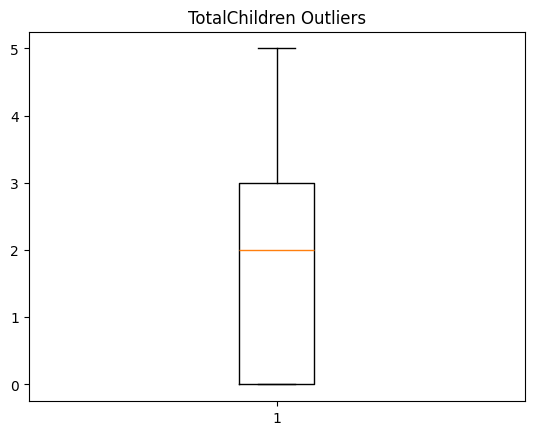

In [45]:
# Using boxplot for TotalChildren Outlier
plt.boxplot(df['TotalChildren'])
plt.title("TotalChildren Outliers")
plt.show()

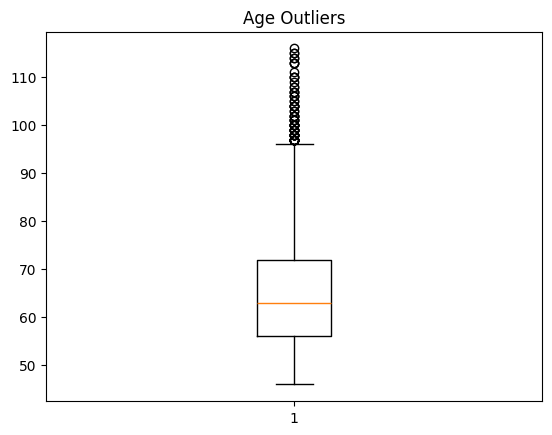

In [46]:
# Using boxplot for Age Outlier
plt.boxplot(df['Age'])
plt.title("Age Outliers")
plt.show()

In [47]:
# Outlier Detection and Removal using IQR

# Select numeric columns
numeric_cols = ['AnnualIncome', 'TotalChildren', 'Age']

for col in numeric_cols:
    
    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define lower and upper limits
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    # Print number of outliers
    print(f"Outliers in {col}: {outliers.shape[0]}")
    
    # Remove outliers
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Check dataset shape after removing outliers
print("Dataset shape after removing outliers:", df.shape)

Outliers in AnnualIncome: 300
Outliers in TotalChildren: 0
Outliers in Age: 73
Dataset shape after removing outliers: (17775, 10)


15. Final Data Validation

In [49]:
# 1️.Check Missing Values
print(df.isnull().sum())

# 2.Check Duplicate Rows
print(df.duplicated().sum())

# 3.Reset Index After Row Removal
df = df.reset_index(drop=True)

# 4.Verify Final Dataset Shape
print(df.shape)

# 5.Data preview
print(df.head(5))

# 6.Save Cleaned Dataset
df.to_csv("2Cleaned_Customer_Data.csv", index=False)

CustomerKey       0
Prefix            0
Gender            0
Age               0
MaritalStatus     0
EducationLevel    0
Occupation        0
AnnualIncome      0
TotalChildren     0
HomeOwner         0
dtype: int64
0
(17775, 10)
   CustomerKey Prefix Gender  Age MaritalStatus EducationLevel    Occupation  \
0        11000    MR.      M   60             M      Bachelors  Professional   
1        11001    MR.      M   61             S      Bachelors  Professional   
2        11002    MR.      M   61             M      Bachelors  Professional   
3        11003    MS.      F   58             S      Bachelors  Professional   
4        11004   MRS.      F   58             S      Bachelors  Professional   

   AnnualIncome  TotalChildren HomeOwner  
0         90000              2         Y  
1         60000              3         N  
2         60000              3         Y  
3         70000              0         N  
4         80000              5         Y  
